In [1]:
import contextlib
import io
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree

from pyforestry.sweden.site.enums import Sweden
from pyforestry.sweden.site.swedish_site import SwedishSite
from pyforestry.sweden.siteindex.sis.hagglund_lundmark_1979 import Hagglund_Lundmark_1979_SIS


class NotebookSwedishSite(SwedishSite):
    def compute_attributes(self):
        return None


CSV_PATH = Path("~/data/RT/standort.csv").expanduser()
PARITY_THRESHOLDS = {
    "mae_max": 1.5,
    "rmse_max": 4.0,
    "abs_bias_max": 1.0,
    "pearson_min": 0.85,
}
BOOTSTRAP_SAMPLES = 400
RANDOM_STATE = 0
SUPPORT_THRESHOLD = 30


# ----------------------------
# A) Load + recode
# ----------------------------
Ytor = pd.read_csv(CSV_PATH, sep=";")

Ytor["BonitetsvisandeTradslag"] = Ytor["BonvisTslag"]
Ytor["Direktlan"] = Ytor["Dlan"]
Ytor["Jordartstextur"] = Ytor["Textur"]
Ytor["incline_percent"] = Ytor["Marklutning"]
Ytor["aspect"] = Ytor["Lutningsriktning"]
Ytor.drop(
    ["Taxar", "Dlan", "BonvisTslag", "Textur", "Lutningsriktning", "Marklutning"],
    axis=1,
    inplace=True,
    errors="ignore",
)


def enum_from_code(enum_cls, code):
    if pd.isna(code):
        return None
    code = int(code)
    if code == 0:
        return None
    for member in enum_cls:
        if member.value.code == code:
            return member
    return None


def map_soil_depth(code):
    if pd.isna(code):
        return None
    mapping = {0.0: 5, 0.05: 4, 0.1: 3, 0.45: 2, 0.8: 1}
    return mapping.get(float(code), None)


def map_climate_zone(code):
    if pd.isna(code):
        return None
    code = int(code)
    if code == 0:
        return None
    return Sweden.ClimateZone.from_code(code)


def map_ditched(before, current):
    return bool(before) or bool(current)


Ytor["soil_depth_code"] = Ytor["Jorddjup"].map(map_soil_depth)
Ytor["soil_depth"] = Ytor["soil_depth_code"].map(
    lambda c: enum_from_code(Sweden.SoilDepth, c) if c is not None else None
)
Ytor["species"] = Ytor["BonitetsvisandeTradslag"].map({10: "Pinus sylvestris", 20: "Picea abies"})
Ytor["ditched"] = Ytor.apply(
    lambda row: map_ditched(row["IsDikatForutvarande"], row["IsDikatNuvarande"]), axis=1
)
Ytor["climate_zone"] = Ytor["Lokalklimat"].apply(map_climate_zone)
Ytor["climate_code"] = Ytor["climate_zone"].apply(lambda cz: cz.value.label if cz else None)
Ytor["peat"] = Ytor["Torvtackning"].apply(lambda x: True if x == 3 else False)
Ytor["gotland"] = Ytor["Direktlan"].apply(lambda x: True if x == 31 else False)
Ytor.drop(
    ["IsDikatForutvarande", "IsDikatNuvarande", "Torvtackning"],
    axis=1,
    inplace=True,
    errors="ignore",
)
Ytor["Latitud"] = Ytor["Latitud"].apply(
    lambda x: 55.21 if x < 55.2 else (69.09 if x > 69.1 else x)
)

Ytor["soil_moisture"] = Ytor["Markfuktighet"].apply(
    lambda x: enum_from_code(Sweden.SoilMoistureEnum, x)
)
Ytor["field_layer"] = Ytor["Faltskikt"].apply(lambda x: enum_from_code(Sweden.FieldLayer, x))
Ytor["bottom_layer"] = Ytor["Bottenskikt"].apply(lambda x: enum_from_code(Sweden.BottomLayer, x))
Ytor["soil_water"] = Ytor["RorligtMarkvatten"].apply(lambda x: enum_from_code(Sweden.SoilWater, x))
Ytor["soil_texture"] = Ytor["Jordartstextur"].apply(
    lambda x: enum_from_code(Sweden.SoilTextureTill, x)
)
Ytor["county"] = Ytor["Direktlan"].apply(
    lambda x: Sweden.County.from_code(int(x)) if pd.notna(x) else None
)
Ytor["county_label"] = Ytor["county"].apply(lambda v: v.value.label if v else None)

Ytor["field_layer_label"] = Ytor["field_layer"].apply(
    lambda v: v.value.english_name if v else None
)
Ytor["soil_moisture_label"] = Ytor["soil_moisture"].apply(
    lambda v: v.value.english_description if v else None
)


# ----------------------------
# B) Compute Hagglund SIS and parity dataset
# ----------------------------
required_cols = [
    "Latitud",
    "Altitud",
    "BonitetsvisandeTradslag",
    "soil_moisture",
    "bottom_layer",
    "field_layer",
    "soil_texture",
    "climate_code",
    "soil_water",
    "soil_depth",
    "incline_percent",
    "aspect",
    "ditched",
    "peat",
    "gotland",
    "species",
    "Direktlan",
    "Longitud",
    "uf_SIS",
]


def compute_sis(row):
    with contextlib.redirect_stdout(io.StringIO()):
        try:
            return Hagglund_Lundmark_1979_SIS(
                latitude=row["Latitud"],
                altitude=row["Altitud"],
                soil_moisture=row["soil_moisture"],
                ground_layer=row["bottom_layer"],
                vegetation=row["field_layer"],
                soil_texture=row["soil_texture"],
                climate_code=row["climate_code"],
                lateral_water=row["soil_water"],
                soil_depth=row["soil_depth"],
                incline_percent=row["incline_percent"],
                aspect=row["aspect"],
                ditched=row["ditched"],
                peat=row["peat"],
                gotland=row["gotland"],
                species=row["species"],
                dlan=row["Direktlan"],
            )
        except Exception:
            return np.nan


valid_mask = Ytor[required_cols].notna().all(axis=1)
valid = Ytor.loc[valid_mask].copy()
valid["sis_hagglund_1979"] = valid.apply(compute_sis, axis=1)
valid["H1979_bin"] = np.floor(valid["sis_hagglund_1979"]).astype("Int64")
compare = valid.dropna(subset=["sis_hagglund_1979", "uf_SIS", "H1979_bin"]).copy()

print(f"Rows with parity data: {len(compare):,}")


# ----------------------------
# C) Parity diagnostics
# ----------------------------
def _parity_metrics(df):
    err = df["sis_hagglund_1979"] - df["uf_SIS"]
    return {
        "n": len(df),
        "mae": float(np.abs(err).mean()),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "bias": float(err.mean()),
        "pearson": float(df["sis_hagglund_1979"].corr(df["uf_SIS"], method="pearson")),
        "spearman": float(df["sis_hagglund_1979"].corr(df["uf_SIS"], method="spearman")),
    }


def _bootstrap_ci(df, metric_key, n_boot=400, random_state=0):
    rng = np.random.default_rng(random_state)
    n = len(df)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        sample = df.iloc[idx]
        vals.append(_parity_metrics(sample)[metric_key])
    q = np.quantile(vals, [0.025, 0.975])
    return float(q[0]), float(q[1])


def _parity_by_group(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col):
        m = _parity_metrics(sub)
        rows.append({group_col: g, **m})
    return pd.DataFrame(rows).sort_values("n", ascending=False)


def validate_sis_parity(df, thresholds, n_boot=400, random_state=0):
    metrics = _parity_metrics(df)
    ci_rows = []
    for k in ["mae", "bias", "rmse"]:
        lo, hi = _bootstrap_ci(df, k, n_boot=n_boot, random_state=random_state)
        ci_rows.append({"metric": k, "value": metrics[k], "ci_low": lo, "ci_high": hi})

    species_table = _parity_by_group(df, "species")
    county_table = _parity_by_group(df, "Direktlan")

    pass_gate = (
        metrics["mae"] <= thresholds["mae_max"]
        and metrics["rmse"] <= thresholds["rmse_max"]
        and abs(metrics["bias"]) <= thresholds["abs_bias_max"]
        and metrics["pearson"] >= thresholds["pearson_min"]
    )

    return {
        "global_metrics": pd.DataFrame([metrics]),
        "bootstrap_ci": pd.DataFrame(ci_rows),
        "species_table": species_table,
        "county_table": county_table,
        "pass_gate": pass_gate,
    }


def plot_bland_altman(df, title="Bland-Altman: sis_hagglund_1979 vs uf_SIS"):
    mean_val = (df["sis_hagglund_1979"] + df["uf_SIS"]) / 2.0
    diff = df["sis_hagglund_1979"] - df["uf_SIS"]
    bias = diff.mean()
    sd = diff.std(ddof=1)

    plt.figure(figsize=(10, 6))
    for sp, sub in df.groupby("species"):
        idx = sub.index
        plt.scatter(mean_val.loc[idx], diff.loc[idx], s=8, alpha=0.25, label=sp)

    plt.axhline(bias, linestyle="--", linewidth=2, color="black", label=f"Bias={bias:.3f}")
    plt.axhline(bias + 1.96 * sd, linestyle=":", linewidth=2, color="red")
    plt.axhline(bias - 1.96 * sd, linestyle=":", linewidth=2, color="red")
    plt.xlabel("Mean of two SIS implementations")
    plt.ylabel("Difference (sis_hagglund_1979 - uf_SIS)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

Rows with parity data: 74,539


Global parity metrics


,n,mae,rmse,bias,pearson,spearman
0,74539,0.719557,4.07698,0.714802,0.845493,0.993316


Bootstrap 95% CI


,metric,value,ci_low,ci_high
0,mae,0.719557,0.689616,0.750039
1,bias,0.714802,0.685444,0.744796
2,rmse,4.076980,3.990310,4.164758


Parity by species


,species,n,mae,rmse,bias,pearson,spearman
0,Picea abies,37044,0.027570,0.769320,0.027324,0.992443,0.999876
1,Pinus sylvestris,37495,1.403219,5.697268,1.394010,0.666284,0.980679


Top counties by absolute bias


,Direktlan,n,mae,rmse,bias,pearson,spearman,abs_bias
10,11,1179,3.714439,9.001984,3.702384,0.399459,0.796925,3.702384
5,6,4464,1.655990,6.138343,1.649850,0.537025,0.948534,1.649850
0,1,4737,1.572052,5.807678,1.568052,0.501201,0.946173,1.568052
11,12,9103,1.297252,5.594927,1.292989,0.652641,0.983039,1.292989
1,2,4358,1.064356,4.899421,1.060657,0.542031,0.977448,1.060657
8,9,2791,0.848662,4.517783,0.845661,0.706103,0.995694,0.845661
3,4,723,0.800336,4.329349,0.795196,0.632677,0.994872,0.795196
2,3,3867,0.668914,3.882219,0.660686,0.605744,0.981522,0.660686
18,21,823,0.616633,3.742427,0.605838,0.867596,0.999692,0.605838
13,14,669,0.579634,3.874786,0.579402,0.764382,0.999599,0.579402


Parity gate passed (informational): False


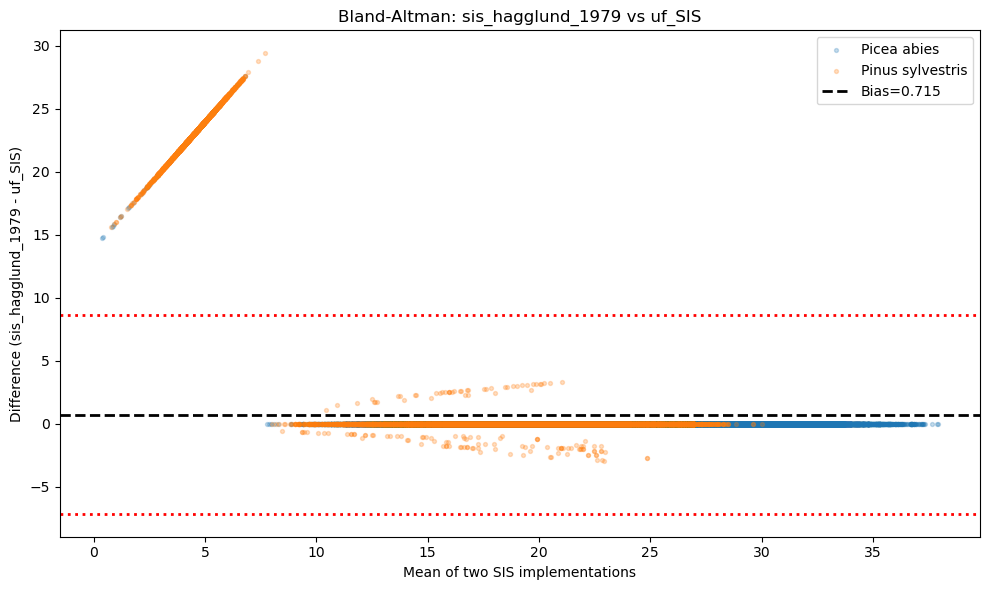

In [2]:
# ----------------------------
# D) Parity diagnostics execution
# ----------------------------
parity = validate_sis_parity(
    compare,
    thresholds=PARITY_THRESHOLDS,
    n_boot=BOOTSTRAP_SAMPLES,
    random_state=RANDOM_STATE,
)

print("Global parity metrics")
display(parity["global_metrics"])

print("Bootstrap 95% CI")
display(parity["bootstrap_ci"])

print("Parity by species")
display(parity["species_table"].sort_values("species"))

print("Top counties by absolute bias")
county_bias = parity["county_table"].copy()
county_bias["abs_bias"] = county_bias["bias"].abs()
display(county_bias.sort_values("abs_bias", ascending=False).head(15))

plot_bland_altman(compare)

PARITY_GATE_PASSED = parity["pass_gate"]
print("Parity gate passed (informational):", PARITY_GATE_PASSED)


In [3]:
# ----------------------------
# E) Tree-only characteristic modeling with grouped CV and fallback
# ----------------------------
MODEL_MAX_ROWS = 120_000
CV_SPLITS = 5
CV_RANDOM_STATE = 7

cat_targets = [
    "field_layer",
    "bottom_layer",
    "soil_texture",
    "soil_moisture",
    "soil_depth",
    "soil_water",
    "ditched",
]
num_targets = [
    "Latitud",
    "Longitud",
    "Altitud",
    "aspect",
    "incline_percent",
]

predictor_cols_county = ["sis_hagglund_1979", "species", "Direktlan"]
predictor_cols_global = ["sis_hagglund_1979", "species"]

for t in cat_targets + num_targets:
    assert t not in predictor_cols_county, f"Leakage: target {t} is present in predictors"
assert "uf_SIS" not in predictor_cols_county, "Leakage: uf_SIS should never be in predictors"

if len(compare) > MODEL_MAX_ROWS:
    model_df = compare.sample(n=MODEL_MAX_ROWS, random_state=RANDOM_STATE).copy()
else:
    model_df = compare.copy()

print(f"Rows used for model fitting/evaluation: {len(model_df):,}")


def to_label(value):
    if value is None or pd.isna(value):
        return "NA"
    if hasattr(value, "value"):
        inner = value.value
        for attr in (
            "label",
            "english_name",
            "english_description",
            "short_name",
            "swedish_name",
            "code",
        ):
            if hasattr(inner, attr):
                return str(getattr(inner, attr))
    return str(value)


def metric_ci(values):
    vals = np.asarray(values, dtype=float)
    mean = float(vals.mean())
    if len(vals) <= 1:
        return mean, mean, mean
    delta = 1.96 * float(vals.std(ddof=1)) / np.sqrt(len(vals))
    return mean, mean - delta, mean + delta


def make_preprocessor(feature_cols):
    cat_cols = [c for c in feature_cols if c == "species"]
    num_cols = [c for c in feature_cols if c != "species"]
    cat_pipeline = Pipeline(
        [
            ("impute", SimpleImputer(strategy="constant", fill_value="NA")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    num_pipeline = Pipeline([("impute", SimpleImputer(strategy="median"))])
    return ColumnTransformer(
        [
            ("cat", cat_pipeline, cat_cols),
            ("num", num_pipeline, num_cols),
        ]
    )


def build_classifier_pipeline(feature_cols):
    return Pipeline(
        [
            ("pre", make_preprocessor(feature_cols)),
            (
                "clf",
                DecisionTreeClassifier(
                    random_state=RANDOM_STATE,
                    max_depth=10,
                    min_samples_leaf=20,
                    class_weight="balanced",
                ),
            ),
        ]
    )


def build_regressor_pipeline(feature_cols):
    return Pipeline(
        [
            ("pre", make_preprocessor(feature_cols)),
            (
                "reg",
                DecisionTreeRegressor(
                    random_state=RANDOM_STATE,
                    max_depth=10,
                    min_samples_leaf=20,
                ),
            ),
        ]
    )


def make_grouped_splits(df, group_col="Direktlan", n_splits=5, random_state=7):
    groups = df[group_col].astype(int).reset_index(drop=True)
    splitter = GroupShuffleSplit(
        n_splits=n_splits,
        test_size=0.2,
        random_state=random_state,
    )
    splits = []
    for train_idx, test_idx in splitter.split(df, groups=groups):
        train_groups = set(groups.iloc[train_idx].tolist())
        test_groups = set(groups.iloc[test_idx].tolist())
        assert train_groups.isdisjoint(test_groups), "Grouped split leaked county groups"
        splits.append((train_idx, test_idx))
    return splits


def reliability_table(confidence, correct, n_bins=10):
    rel = pd.DataFrame({"confidence": confidence, "correct": correct.astype(int)})
    unique_conf = rel["confidence"].nunique()
    if unique_conf < 2:
        return pd.DataFrame(
            [
                {
                    "bin": "all",
                    "mean_confidence": float(rel["confidence"].mean()),
                    "accuracy": float(rel["correct"].mean()),
                    "n": len(rel),
                }
            ]
        )
    q = min(n_bins, unique_conf)
    rel["bin"] = pd.qcut(rel["confidence"], q=q, duplicates="drop")
    out = (
        rel.groupby("bin", observed=False)
        .agg(
            mean_confidence=("confidence", "mean"),
            accuracy=("correct", "mean"),
            n=("correct", "size"),
        )
        .reset_index()
    )
    return out


def evaluate_classifier_target(X, y, splits, feature_cols):
    macro_f1 = []
    bal_acc = []
    conf_all = []
    corr_all = []

    for train_idx, test_idx in splits:
        pipe = build_classifier_pipeline(feature_cols)
        X_train = X.iloc[train_idx][feature_cols]
        X_test = X.iloc[test_idx][feature_cols]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        proba = pipe.predict_proba(X_test)

        macro_f1.append(f1_score(y_test, pred, average="macro", zero_division=0))
        bal_acc.append(balanced_accuracy_score(y_test, pred))

        conf_all.append(np.max(proba, axis=1))
        corr_all.append((pred == y_test.to_numpy()).astype(int))

    f1_mean, f1_lo, f1_hi = metric_ci(macro_f1)
    ba_mean, ba_lo, ba_hi = metric_ci(bal_acc)

    summary = {
        "macro_f1_mean": f1_mean,
        "macro_f1_ci_low": f1_lo,
        "macro_f1_ci_high": f1_hi,
        "balanced_accuracy_mean": ba_mean,
        "balanced_accuracy_ci_low": ba_lo,
        "balanced_accuracy_ci_high": ba_hi,
    }
    rel = reliability_table(np.concatenate(conf_all), np.concatenate(corr_all))
    return summary, rel


def evaluate_regressor_target(X, y, splits, feature_cols):
    maes = []
    rmses = []
    q90s = []

    for train_idx, test_idx in splits:
        pipe = build_regressor_pipeline(feature_cols)
        X_train = X.iloc[train_idx][feature_cols]
        X_test = X.iloc[test_idx][feature_cols]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        err = y_test.to_numpy() - pred
        maes.append(mean_absolute_error(y_test, pred))
        rmses.append(np.sqrt(mean_squared_error(y_test, pred)))
        q90s.append(float(np.quantile(np.abs(err), 0.9)))

    mae_mean, mae_lo, mae_hi = metric_ci(maes)
    rmse_mean, rmse_lo, rmse_hi = metric_ci(rmses)
    q90_mean, q90_lo, q90_hi = metric_ci(q90s)

    summary = {
        "mae_mean": mae_mean,
        "mae_ci_low": mae_lo,
        "mae_ci_high": mae_hi,
        "rmse_mean": rmse_mean,
        "rmse_ci_low": rmse_lo,
        "rmse_ci_high": rmse_hi,
        "abs_residual_q90_mean": q90_mean,
        "abs_residual_q90_ci_low": q90_lo,
        "abs_residual_q90_ci_high": q90_hi,
    }
    return summary


splits = make_grouped_splits(
    model_df,
    group_col="Direktlan",
    n_splits=CV_SPLITS,
    random_state=CV_RANDOM_STATE,
)

X_county = model_df[predictor_cols_county].reset_index(drop=True)
X_global = model_df[predictor_cols_global].reset_index(drop=True)

cat_models_county = {}
cat_models_global = {}
num_models_county = {}
num_models_global = {}

cat_eval_rows = []
num_eval_rows = []
cat_reliability = {}
num_q90_county = {}
num_q90_global = {}

for target in cat_targets:
    y = model_df[target].map(to_label).fillna("NA").astype(str).reset_index(drop=True)
    summary, rel = evaluate_classifier_target(X_county, y, splits, predictor_cols_county)
    cat_eval_rows.append({"target": target, **summary})
    cat_reliability[target] = rel

    model_c = build_classifier_pipeline(predictor_cols_county)
    model_c.fit(X_county[predictor_cols_county], y)
    cat_models_county[target] = model_c

    model_g = build_classifier_pipeline(predictor_cols_global)
    model_g.fit(X_global[predictor_cols_global], y)
    cat_models_global[target] = model_g

for target in num_targets:
    y = model_df[target].astype(float).reset_index(drop=True)
    summary = evaluate_regressor_target(X_county, y, splits, predictor_cols_county)
    num_eval_rows.append({"target": target, **summary})

    num_q90_county[target] = summary["abs_residual_q90_mean"]

    model_c = build_regressor_pipeline(predictor_cols_county)
    model_c.fit(X_county[predictor_cols_county], y)
    num_models_county[target] = model_c

    model_g = build_regressor_pipeline(predictor_cols_global)
    model_g.fit(X_global[predictor_cols_global], y)
    num_models_global[target] = model_g

    summary_g = evaluate_regressor_target(X_global, y, splits, predictor_cols_global)
    num_q90_global[target] = summary_g["abs_residual_q90_mean"]

cat_eval_df = pd.DataFrame(cat_eval_rows).sort_values("target")
num_eval_df = pd.DataFrame(num_eval_rows).sort_values("target")

print("Categorical target metrics (grouped CV)")
display(cat_eval_df)

print("Numeric target metrics (grouped CV)")
display(num_eval_df)

print("Reliability table example: field_layer")
display(cat_reliability["field_layer"])


def _mode_or_none(series):
    s = series.dropna()
    if s.empty:
        return None
    vc = s.value_counts()
    return vc.index[0] if not vc.empty else None


def _median_or_none(series):
    s = series.dropna()
    return float(s.median()) if not s.empty else None


def _characteristic_from_subset(subset):
    return {
        "Latitud": _median_or_none(subset["Latitud"]),
        "Longitud": _median_or_none(subset["Longitud"]),
        "Altitud": _median_or_none(subset["Altitud"]),
        "aspect": _median_or_none(subset["aspect"]),
        "incline_percent": _median_or_none(subset["incline_percent"]),
        "field_layer": _mode_or_none(subset["field_layer"]),
        "bottom_layer": _mode_or_none(subset["bottom_layer"]),
        "soil_texture": _mode_or_none(subset["soil_texture"]),
        "soil_moisture": _mode_or_none(subset["soil_moisture"]),
        "soil_depth": _mode_or_none(subset["soil_depth"]),
        "soil_water": _mode_or_none(subset["soil_water"]),
        "ditched": _mode_or_none(subset["ditched"]),
    }


from pyforestry.sweden.siteindex.sis.generated_site_category_trees import (
    predict_site_categories_county_tree,
)


global_defaults = _characteristic_from_subset(compare)
support_by_bin = compare.groupby(["species", "Direktlan", "H1979_bin"]).size().to_dict()
support_by_county = compare.groupby(["species", "Direktlan"]).size().to_dict()


def _pred_float(value):
    try:
        v = float(value)
    except (TypeError, ValueError):
        return None
    return None if np.isnan(v) else v


def _estimate_sis_for_generated_site(*, species, county_code, site):
    with contextlib.redirect_stdout(io.StringIO()):
        try:
            achieved = Hagglund_Lundmark_1979_SIS(
                latitude=site.latitude,
                altitude=site.altitude,
                soil_moisture=site.soil_moisture,
                ground_layer=site.bottom_layer,
                vegetation=site.field_layer,
                soil_texture=site.soil_texture,
                climate_code=None,
                lateral_water=site.soil_water,
                soil_depth=site.soil_depth,
                incline_percent=site.incline_percent if site.incline_percent is not None else 0.0,
                aspect=site.aspect if site.aspect is not None else 0,
                ditched=bool(site.ditched),
                peat=False,
                gotland=county_code == Sweden.County.GOTLAND.value.code,
                coast=False,
                limes_norrlandicus=bool(site.latitude > 60),
                nfi_adjustments=True,
                species=species,
                dlan=county_code,
            )
        except Exception:
            return None
    return _pred_float(achieved)


def build_site_from_inputs(
    species: str,
    sis_value: float,
    county_code: int,
    return_diagnostics: bool = True,
):
    pred_bin = int(np.floor(sis_value))
    county_code = int(county_code)

    support_n = int(support_by_bin.get((species, county_code, pred_bin), 0))
    county_support_n = int(support_by_county.get((species, county_code), 0))

    preds_cat = predict_site_categories_county_tree(
        sis_hagglund_1979=sis_value,
        species=species,
        Direktlan=county_code,
    )

    intervals = {}
    if support_n >= SUPPORT_THRESHOLD:
        feature_cols = predictor_cols_county
        num_models = num_models_county
        num_q90 = num_q90_county
        model_row = {
            "sis_hagglund_1979": sis_value,
            "species": species,
            "Direktlan": county_code,
        }
        fallback_numeric = "none"
    elif county_support_n >= SUPPORT_THRESHOLD:
        feature_cols = predictor_cols_global
        num_models = num_models_global
        num_q90 = num_q90_global
        model_row = {
            "sis_hagglund_1979": sis_value,
            "species": species,
        }
        fallback_numeric = "global_tree"
    else:
        model_row = None
        fallback_numeric = "global_defaults"

    if model_row is not None:
        example_input = pd.DataFrame([model_row])
        preds_num = {
            t: _pred_float(num_models[t].predict(example_input[feature_cols])[0])
            for t in num_targets
        }
        for t in num_targets:
            center = preds_num[t]
            q = float(num_q90.get(t, np.nan))
            if center is None or np.isnan(q):
                intervals[t] = (None, None)
            else:
                intervals[t] = (center - q, center + q)
    else:
        preds_num = {
            "Latitud": global_defaults["Latitud"],
            "Longitud": global_defaults["Longitud"],
            "Altitud": global_defaults["Altitud"],
            "aspect": global_defaults["aspect"],
            "incline_percent": global_defaults["incline_percent"],
        }

    latitude = preds_num["Latitud"] or global_defaults["Latitud"]
    longitude = preds_num["Longitud"] or global_defaults["Longitud"]
    altitude = preds_num["Altitud"] or global_defaults["Altitud"]

    if latitude is None or longitude is None:
        raise ValueError("Latitude/Longitude missing for site construction.")

    site = NotebookSwedishSite(
        latitude=latitude,
        longitude=longitude,
        altitude=altitude,
        field_layer=preds_cat["field_layer"] or global_defaults["field_layer"],
        bottom_layer=preds_cat["bottom_layer"] or global_defaults["bottom_layer"],
        soil_texture=preds_cat["soil_texture"] or global_defaults["soil_texture"],
        soil_moisture=preds_cat["soil_moisture"] or global_defaults["soil_moisture"],
        soil_depth=preds_cat["soil_depth"] or global_defaults["soil_depth"],
        soil_water=preds_cat["soil_water"] or global_defaults["soil_water"],
        aspect=(
            preds_num["aspect"] if preds_num["aspect"] is not None else global_defaults["aspect"]
        ),
        incline_percent=(
            preds_num["incline_percent"]
            if preds_num["incline_percent"] is not None
            else global_defaults["incline_percent"]
        ),
        ditched=(
            preds_cat["ditched"]
            if preds_cat["ditched"] is not None
            else global_defaults["ditched"]
        ),
    )

    achieved_sis = _estimate_sis_for_generated_site(
        species=species,
        county_code=county_code,
        site=site,
    )
    requested_sis = float(sis_value)
    sis_abs_error = None if achieved_sis is None else abs(achieved_sis - requested_sis)
    sis_rel_error_pct = (
        None
        if achieved_sis is None or requested_sis == 0
        else 100.0 * sis_abs_error / abs(requested_sis)
    )

    diagnostics = {
        "support_n": support_n,
        "county_support_n": county_support_n,
        "fallback_numeric": fallback_numeric,
        "warning_flag": fallback_numeric != "none",
        "prediction_intervals_q90": intervals,
        "requested_sis": requested_sis,
        "achieved_sis": achieved_sis,
        "sis_abs_error": sis_abs_error,
        "sis_rel_error_pct": sis_rel_error_pct,
        "within_0_5m": sis_abs_error is not None and sis_abs_error <= 0.5,
        "within_1_0m": sis_abs_error is not None and sis_abs_error <= 1.0,
    }

    if return_diagnostics:
        return pred_bin, site, diagnostics
    return pred_bin, site



Rows used for model fitting/evaluation: 74,539
Categorical target metrics (grouped CV)


,target,macro_f1_mean,macro_f1_ci_low,macro_f1_ci_high,balanced_accuracy_mean,balanced_accuracy_ci_low,balanced_accuracy_ci_high
1,bottom_layer,0.288649,0.265975,0.311324,0.356812,0.343259,0.370366
6,ditched,0.480131,0.454832,0.505430,0.579437,0.555722,0.603151
0,field_layer,0.110377,0.097526,0.123228,0.186866,0.163934,0.209799
4,soil_depth,0.363876,0.304148,0.423604,0.503128,0.409656,0.596600
3,soil_moisture,0.243880,0.229451,0.258309,0.331064,0.304737,0.357391
2,soil_texture,0.143203,0.120694,0.165712,0.269184,0.230341,0.308028
5,soil_water,0.427749,0.413845,0.441654,0.451894,0.424397,0.479391


Numeric target metrics (grouped CV)


,target,mae_mean,mae_ci_low,mae_ci_high,rmse_mean,rmse_ci_low,rmse_ci_high,abs_residual_q90_mean,abs_residual_q90_ci_low,abs_residual_q90_ci_high
2,Altitud,115.735806,100.407912,131.063699,148.614671,127.651026,169.578316,245.269151,210.519411,280.018891
0,Latitud,0.835524,0.657754,1.013294,0.945326,0.734177,1.156474,1.435050,1.070118,1.799982
1,Longitud,1.839778,1.365673,2.313882,2.331130,1.795325,2.866936,3.906044,3.004382,4.807706
3,aspect,91.383007,90.105060,92.660955,106.323964,104.494681,108.153246,164.442004,162.546786,166.337222
4,incline_percent,6.445568,6.201246,6.689891,9.230626,8.662400,9.798852,13.699040,12.843650,14.554429


Reliability table example: field_layer


,bin,mean_confidence,accuracy,n
0,"(0.145, 0.224]",0.205101,0.122644,7746
1,"(0.224, 0.273]",0.254506,0.259932,7375
2,"(0.273, 0.302]",0.283315,0.133603,7163
3,"(0.302, 0.326]",0.311299,0.130876,7488
4,"(0.326, 0.369]",0.344002,0.190211,7376
5,"(0.369, 0.402]",0.385341,0.204353,7306
6,"(0.402, 0.465]",0.436334,0.151775,7465
7,"(0.465, 0.535]",0.496552,0.125736,7476
8,"(0.535, 0.725]",0.611001,0.177862,7354
9,"(0.725, 1.0]",0.847533,0.136494,7319


In [4]:
# ----------------------------
# F) Example usage: generated categorical site predictions + SIS closeness
# ----------------------------
examples = [
    {"species": "Picea abies", "sis_value": 26.4, "county_code": 14},
    {"species": "Pinus sylvestris", "sis_value": 22.8, "county_code": 12},
]

for ex in examples:
    pred_bin, site, diagnostics = build_site_from_inputs(
        species=ex["species"],
        sis_value=ex["sis_value"],
        county_code=ex["county_code"],
    )

    print(
        f"species={ex['species']}, county={ex['county_code']}, requested_SIS={ex['sis_value']:.2f}"
    )
    print(f"Predicted H1979_bin: {pred_bin}")
    print(site)

    closeness = pd.DataFrame(
        [
            {
                "requested_sis": diagnostics["requested_sis"],
                "achieved_sis": diagnostics["achieved_sis"],
                "sis_abs_error": diagnostics["sis_abs_error"],
                "sis_rel_error_pct": diagnostics["sis_rel_error_pct"],
                "within_0_5m": diagnostics["within_0_5m"],
                "within_1_0m": diagnostics["within_1_0m"],
                "fallback_numeric": diagnostics["fallback_numeric"],
                "support_n": diagnostics["support_n"],
                "county_support_n": diagnostics["county_support_n"],
            }
        ]
    )
    display(closeness)



Predicted H1979_bin: 26
NotebookSwedishSite(latitude=59.79718309859154, longitude=14.572477064220184, altitude=232.89119170984455, field_layer=<SwedenFieldLayer.BROADLEAVED_GRASS: Vegetation(code=8, swedish_name='Bredbl. gräs', english_name='Broadleaved grass', index=2.5)>, bottom_layer=<SwedenBottomLayer.SWAMP_MOSS: BottomLayerType(code=5, english_name='Swamp moss type', swedish_name='Sumpmosstyp')>, soil_texture=<SwedenSoilTextureTill.SILTY_SAND: SoilTextureCategory(code=5, swedish_name='Sandig-moig morän', english_name='Silty-sandy till', short_name='Fine sand')>, soil_moisture=<SwedenSoilMoisture.MESIC_MOIST: SoilMoistureData(code=3, swedish_description='frisk-fuktig', english_description='Mesic-moist (subsoil water depth <1 m)')>, soil_depth=<SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcrops.')>, soil_water=<SwedenSoilWater.LONGER_PERIODS: SoilWaterCat(code=3, swedish_des

,support_n,county_support_n,fallback,warning_flag,prediction_intervals_q90
0,84,425,none,False,"{'Latitud': (58.36213330758682, 61.23223288959..."


Predicted H1979_bin: 22
NotebookSwedishSite(latitude=60.76747352496223, longitude=14.360975609756101, altitude=349.6088379705401, field_layer=<SwedenFieldLayer.BILBERRY: Vegetation(code=13, swedish_name='Blåbär', english_name='European blueberry, bilberry', index=0)>, bottom_layer=<SwedenBottomLayer.FRESH_MOSS: BottomLayerType(code=6, english_name='Fresh moss type', swedish_name='Friskmosstyp')>, soil_texture=<SwedenSoilTextureTill.SILTY_SAND: SoilTextureCategory(code=5, swedish_name='Sandig-moig morän', english_name='Silty-sandy till', short_name='Fine sand')>, soil_moisture=<SwedenSoilMoisture.MESIC: SoilMoistureData(code=2, swedish_description='frisk', english_description='Mesic (subsoil water depth = 1-2 m)')>, soil_depth=<SwedenSoilDepth.DEEP: SoilDepthCat(code=1, swedish_description='Mäktigt >70 cm. Inga synliga hällar', english_description='Deep >70cm. No visible stone outcrops.')>, soil_water=<SwedenSoilWater.SELDOM_NEVER: SoilWaterCat(code=1, swedish_description='saknas', engl

,support_n,county_support_n,fallback,warning_flag,prediction_intervals_q90
0,657,6140,none,False,"{'Latitud': (59.332423733957505, 62.2025233159..."


|--- sis_hagglund_1979 <= 20.30
|   |--- species_Picea abies <= 0.50
|   |   |--- sis_hagglund_1979 <= 16.38
|   |   |   |--- sis_hagglund_1979 <= 12.69
|   |   |   |   |--- Direktlan <= 4.00
|   |   |   |   |   |--- sis_hagglund_1979 <= 12.51
|   |   |   |   |   |   |--- sis_hagglund_1979 <= 11.97
|   |   |   |   |   |   |   |--- sis_hagglund_1979 <= 10.05
|   |   |   |   |   |   |   |   |--- class: Horsetail, Equisetum ssp.
|   |   |   |   |   |   |   |--- sis_hagglund_1979 >  10.05
|   |   |   |   |   |   |   |   |--- sis_hagglund_1979 <= 11.32
|   |   |   |   |   |   |   |   |   |--- sis_hagglund_1979 <= 10.92
|   |   |   |   |   |   |   |   |   |   |--- class: Sedge, low
|   |   |   |   |   |   |   |   |   |--- sis_hagglund_1979 >  10.92
|   |   |   |   |   |   |   |   |   |   |--- class: Poor shrub
|   |   |   |   |   |   |   |   |--- sis_hagglund_1979 >  11.32
|   |   |   |   |   |   |   |   |   |--- Direktlan <= 1.50
|   |   |   |   |   |   |   |   |   |   |--- class: Horsetail

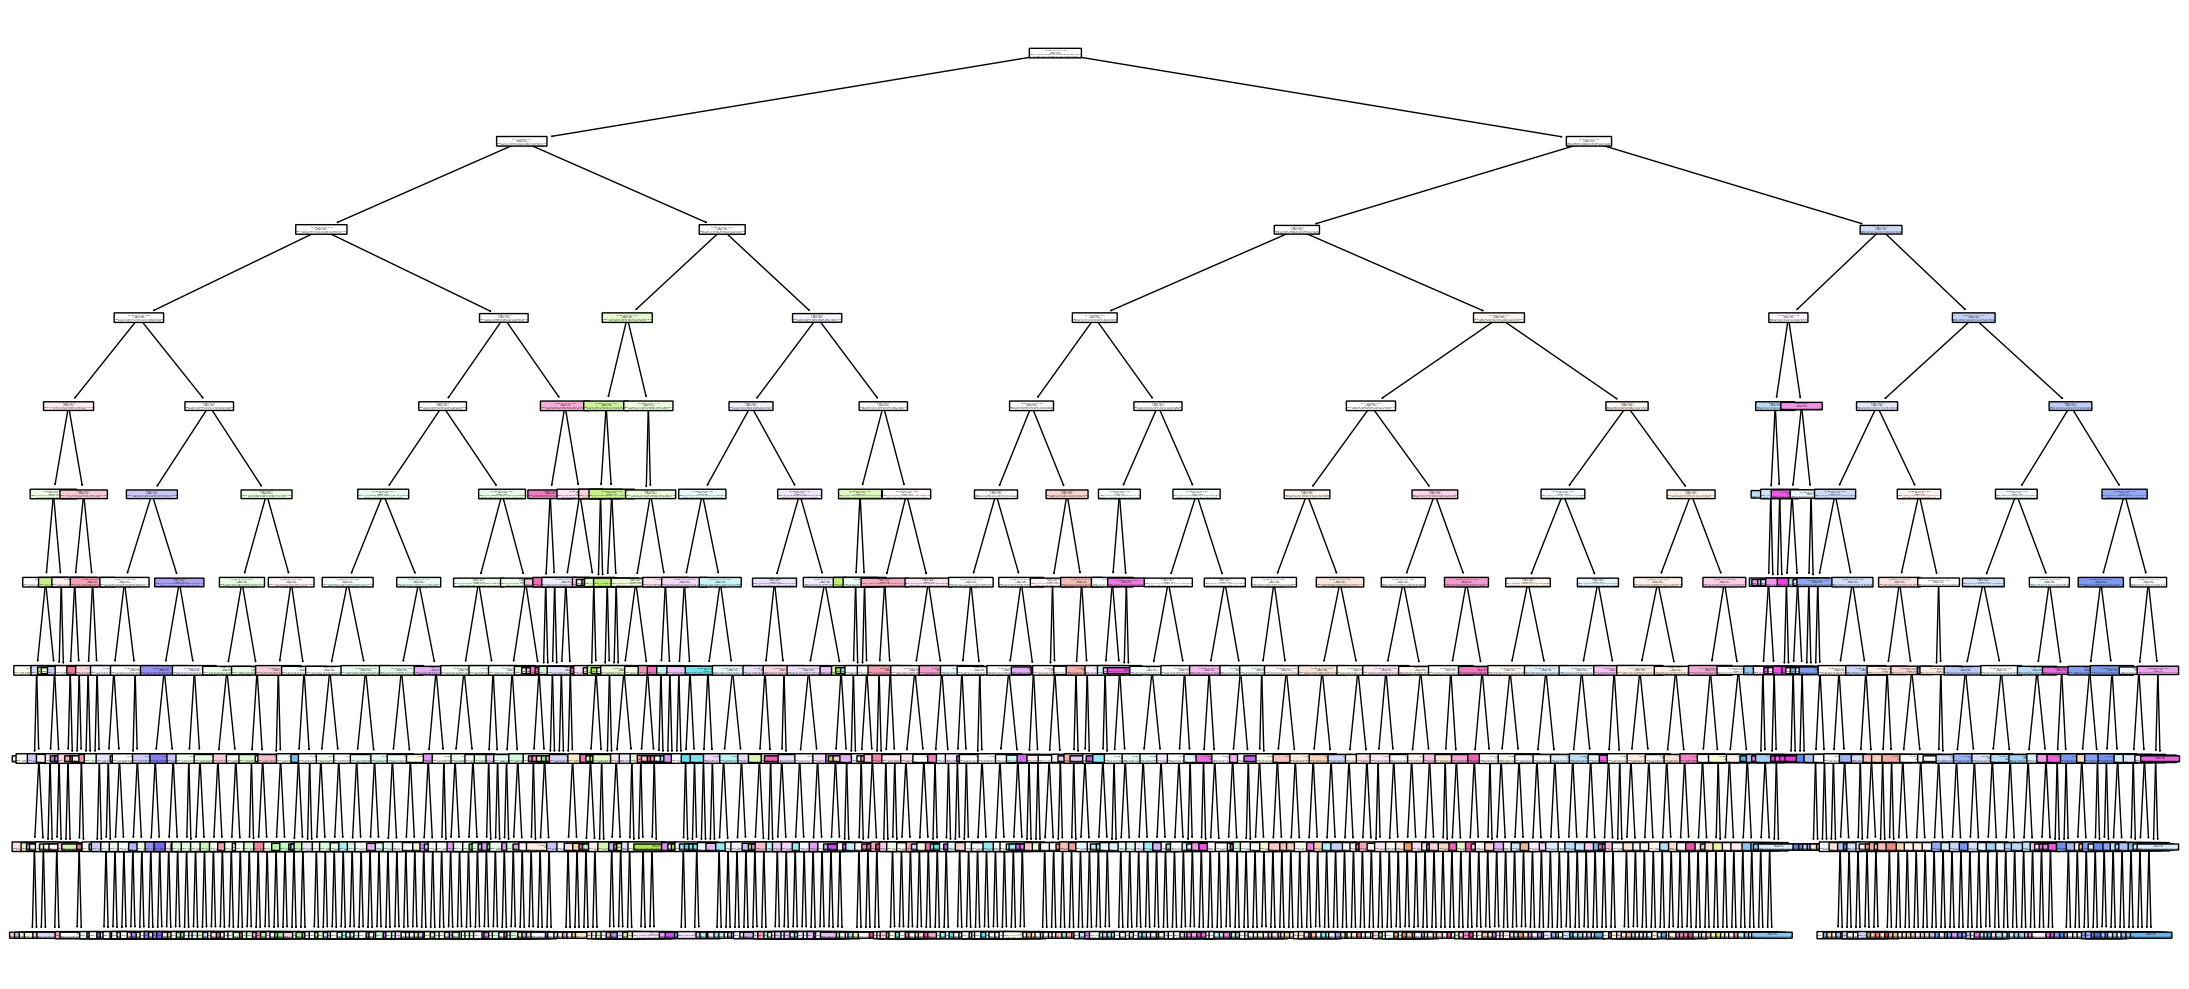

In [5]:
# ----------------------------
# G) Export representative tree rules
# ----------------------------
def transformed_feature_names(pre, feature_cols):
    cat_cols = [c for c in feature_cols if c == "species"]
    num_cols = [c for c in feature_cols if c != "species"]
    cat_pipe = pre.named_transformers_["cat"]
    ohe = cat_pipe.named_steps["onehot"]
    return list(ohe.get_feature_names_out(cat_cols)) + num_cols


representative_target = "field_layer"
representative_pipe = cat_models_county[representative_target]
representative_tree = representative_pipe.named_steps["clf"]
representative_pre = representative_pipe.named_steps["pre"]
representative_feature_names = transformed_feature_names(
    representative_pre,
    predictor_cols_county,
)

rules = export_text(
    representative_tree,
    feature_names=representative_feature_names,
)
print(rules)

plt.figure(figsize=(22, 10))
plot_tree(
    representative_tree,
    feature_names=representative_feature_names,
    filled=True,
    rounded=True,
)
plt.tight_layout()

Fallback coverage (using SUPPORT_THRESHOLD logic)


,fallback,n,share_pct
0,none,70508,94.592093
1,global_tree,3990,5.352903
2,global_defaults,41,0.055005


Fallback split by species


,species,fallback,n,share_pct
2,Picea abies,none,34865,94.117806
1,Picea abies,global_tree,2155,5.817406
0,Picea abies,global_defaults,24,0.064788
5,Pinus sylvestris,none,35643,95.060675
4,Pinus sylvestris,global_tree,1835,4.893986
3,Pinus sylvestris,global_defaults,17,0.045339


Worst species/county residual segments (n >= 250)


,species,Direktlan,n,mae,bias,rmse,abs_bias
38,Pinus sylvestris,11,1033,4.239386,4.225666,9.617118,4.225666
33,Pinus sylvestris,6,3260,2.261121,2.252809,7.173745,2.252809
46,Pinus sylvestris,21,261,1.943842,1.910370,6.645581,1.910370
28,Pinus sylvestris,1,3840,1.914960,1.910081,6.421125,1.910081
39,Pinus sylvestris,12,6140,1.906351,1.900153,6.786722,1.900153
36,Pinus sylvestris,9,1824,1.285458,1.281012,5.560869,1.281012
29,Pinus sylvestris,2,3672,1.263150,1.258810,5.337490,1.258810
40,Pinus sylvestris,13,4426,1.258235,1.240055,5.572503,1.240055
31,Pinus sylvestris,4,473,1.223223,1.215492,5.352555,1.215492
35,Pinus sylvestris,8,531,1.078083,1.068876,5.139032,1.068876


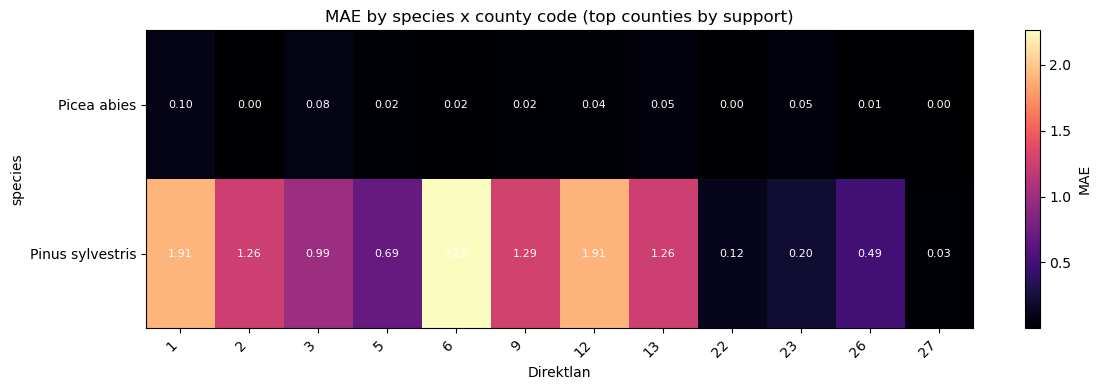

In [6]:
# ----------------------------
# F) Fallback coverage and residual heatmap diagnostics
# ----------------------------
support_bin = (
    compare.groupby(["species", "Direktlan", "H1979_bin"], observed=False)
    .size()
    .rename("support_n")
    .reset_index()
)
support_county = (
    compare.groupby(["species", "Direktlan"], observed=False)
    .size()
    .rename("county_support_n")
    .reset_index()
)

diagnostics_df = (
    compare[["species", "Direktlan", "H1979_bin", "sis_hagglund_1979", "uf_SIS"]]
    .merge(support_bin, on=["species", "Direktlan", "H1979_bin"], how="left")
    .merge(support_county, on=["species", "Direktlan"], how="left")
)

diagnostics_df["fallback"] = np.where(
    diagnostics_df["support_n"] >= SUPPORT_THRESHOLD,
    "none",
    np.where(
        diagnostics_df["county_support_n"] >= SUPPORT_THRESHOLD,
        "global_tree",
        "global_defaults",
    ),
)
diagnostics_df["error"] = diagnostics_df["sis_hagglund_1979"] - diagnostics_df["uf_SIS"]
diagnostics_df["abs_error"] = diagnostics_df["error"].abs()

fallback_summary = diagnostics_df["fallback"].value_counts().rename_axis("fallback").to_frame("n")
fallback_summary["share_pct"] = 100.0 * fallback_summary["n"] / len(diagnostics_df)
print("Fallback coverage (using SUPPORT_THRESHOLD logic)")
display(fallback_summary.reset_index().sort_values("n", ascending=False))

fallback_by_species = (
    diagnostics_df.groupby(["species", "fallback"], observed=False)
    .size()
    .rename("n")
    .reset_index()
)
fallback_by_species["share_pct"] = 100.0 * fallback_by_species["n"] / fallback_by_species.groupby("species")["n"].transform("sum")
print("Fallback split by species")
display(fallback_by_species.sort_values(["species", "n"], ascending=[True, False]))

min_n = 250
segment_residuals = (
    diagnostics_df.groupby(["species", "Direktlan"], observed=False)
    .agg(
        n=("error", "size"),
        mae=("abs_error", "mean"),
        bias=("error", "mean"),
        rmse=("error", lambda s: float(np.sqrt(np.mean(np.square(s))))),
    )
    .reset_index()
)
worst_segments = (
    segment_residuals.loc[segment_residuals["n"] >= min_n]
    .assign(abs_bias=lambda df: df["bias"].abs())
    .sort_values(["abs_bias", "mae"], ascending=False)
    .head(20)
)
print(f"Worst species/county residual segments (n >= {min_n})")
display(worst_segments)

top_counties = diagnostics_df["Direktlan"].value_counts().head(12).index.tolist()
heat = (
    diagnostics_df.loc[diagnostics_df["Direktlan"].isin(top_counties)]
    .groupby(["species", "Direktlan"], observed=False)["abs_error"]
    .mean()
    .unstack("Direktlan")
    .sort_index()
)

plt.figure(figsize=(12, 4))
im = plt.imshow(heat.to_numpy(), aspect="auto", cmap="magma")
plt.yticks(range(len(heat.index)), heat.index)
plt.xticks(range(len(heat.columns)), [str(c) for c in heat.columns], rotation=45, ha="right")
plt.title("MAE by species x county code (top counties by support)")
plt.xlabel("Direktlan")
plt.ylabel("species")
cbar = plt.colorbar(im)
cbar.set_label("MAE")

for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        value = heat.iat[r, c]
        if pd.notna(value):
            plt.text(c, r, f"{value:.2f}", ha="center", va="center", fontsize=8, color="white")

plt.tight_layout()
plt.show()


In [7]:
# ----------------------------
# H) Export all categorical county trees to a package-ready Python module
# ----------------------------
import importlib.util
import json
import pprint
from pathlib import Path


def _literal(value):
    return pprint.pformat(value, width=88, compact=False, sort_dicts=False)


def _extract_classifier_payload(pipe, *, feature_cols):
    pre = pipe.named_steps["pre"]
    clf = pipe.named_steps["clf"]

    cat_pipe = pre.named_transformers_["cat"]
    cat_imputer = cat_pipe.named_steps["impute"]
    ohe = cat_pipe.named_steps["onehot"]

    species_categories = [str(v) for v in ohe.categories_[0].tolist()]
    species_fill = str(cat_imputer.fill_value)

    num_pipe = pre.named_transformers_["num"]
    num_imputer = num_pipe.named_steps["impute"]
    num_cols = [c for c in feature_cols if c != "species"]
    numeric_defaults = {
        col: float(stat)
        for col, stat in zip(num_cols, num_imputer.statistics_)
    }

    feature_names = list(ohe.get_feature_names_out(["species"])) + num_cols
    tree = clf.tree_

    payload = {
        "feature_names": feature_names,
        "tree_feature": tree.feature.tolist(),
        "tree_threshold": [float(x) for x in tree.threshold.tolist()],
        "tree_left": tree.children_left.tolist(),
        "tree_right": tree.children_right.tolist(),
        "tree_values": tree.value[:, 0, :].tolist(),
        "class_labels": [str(c) for c in clf.classes_.tolist()],
    }
    shared_meta = {
        "species_categories": species_categories,
        "species_fill_value": species_fill,
        "numeric_defaults": numeric_defaults,
    }
    return payload, shared_meta


def export_site_category_pipelines_to_python_module(
    cat_models,
    *,
    feature_cols,
    function_name: str,
) -> str:
    if not cat_models:
        raise ValueError("cat_models is empty.")

    target_models = {}
    shared_meta = None

    for target in cat_targets:
        payload, meta = _extract_classifier_payload(
            cat_models[target],
            feature_cols=feature_cols,
        )
        target_models[target] = payload

        if shared_meta is None:
            shared_meta = meta
        elif meta != shared_meta:
            raise ValueError(
                "All classifier pipelines must share the same preprocessing metadata."
            )

    source = f'''"""Auto-generated from SIS_test.ipynb.

Do not edit manually.
"""

from __future__ import annotations

from typing import Any

from pyforestry.base.helpers import enum_code
from pyforestry.sweden.site.enums import Sweden

CAT_TARGETS = [
    {", ".join(json.dumps(t, ensure_ascii=False) for t in cat_targets)}
]
SPECIES_CATEGORIES = {_literal(shared_meta["species_categories"])}
SPECIES_FILL_VALUE = {json.dumps(shared_meta["species_fill_value"], ensure_ascii=False)}
NUMERIC_DEFAULTS = {_literal(shared_meta["numeric_defaults"])}
TARGET_MODELS = {_literal(target_models)}
_SPECIES_CANONICAL = {{category.casefold(): category for category in SPECIES_CATEGORIES}}

__all__ = ["{function_name}"]


def _coerce_float(value: Any, default: float) -> float:
    try:
        v = float(value)
    except (TypeError, ValueError):
        return float(default)
    if v != v:
        return float(default)
    return v


def _coerce_species(value: Any) -> str:
    if value is None:
        return SPECIES_FILL_VALUE
    if hasattr(value, "full_name"):
        value = value.full_name
    species_value = str(value).strip()
    return _SPECIES_CANONICAL.get(species_value.casefold(), species_value)


def _predict_label_for_target(target_name: str, features: dict[str, float]) -> str:
    model = TARGET_MODELS[target_name]
    node = 0
    while model["tree_feature"][node] != -2:
        feature_idx = model["tree_feature"][node]
        feature_name = model["feature_names"][feature_idx]
        feature_value = features.get(feature_name, 0.0)
        if feature_value <= model["tree_threshold"][node]:
            node = model["tree_left"][node]
        else:
            node = model["tree_right"][node]

    scores = model["tree_values"][node]
    best_index = max(range(len(scores)), key=lambda i: scores[i])
    return model["class_labels"][best_index]


def _to_enum(enum_cls, label: str):
    if label in (None, "NA", "nan"):
        return None
    for member in enum_cls:
        inner = member.value
        for attr in (
            "label",
            "english_name",
            "english_description",
            "short_name",
            "swedish_name",
            "code",
        ):
            if hasattr(inner, attr) and str(getattr(inner, attr)) == str(label):
                return member
    return None


def _to_bool(label: str):
    if label in (None, "NA", "nan"):
        return None
    return str(label).strip().lower() == "true"


def {function_name}(
    *,
    sis_hagglund_1979: Any,
    species: Any,
    Direktlan: Any,
) -> dict[str, Any]:
    species_value = _coerce_species(species)

    features = {{}}
    for category in SPECIES_CATEGORIES:
        features[f"species_{{category}}"] = 1.0 if species_value == category else 0.0

    features["sis_hagglund_1979"] = _coerce_float(
        sis_hagglund_1979,
        NUMERIC_DEFAULTS["sis_hagglund_1979"],
    )
    features["Direktlan"] = _coerce_float(
        enum_code(Direktlan),
        NUMERIC_DEFAULTS["Direktlan"],
    )

    raw = {{target: _predict_label_for_target(target, features) for target in CAT_TARGETS}}

    return {{
        "field_layer": _to_enum(Sweden.FieldLayer, raw["field_layer"]),
        "bottom_layer": _to_enum(Sweden.BottomLayer, raw["bottom_layer"]),
        "soil_texture": _to_enum(Sweden.SoilTextureTill, raw["soil_texture"])
        or _to_enum(Sweden.SoilTextureSediment, raw["soil_texture"]),
        "soil_moisture": _to_enum(Sweden.SoilMoistureEnum, raw["soil_moisture"]),
        "soil_depth": _to_enum(Sweden.SoilDepth, raw["soil_depth"]),
        "soil_water": _to_enum(Sweden.SoilWater, raw["soil_water"]),
        "ditched": _to_bool(raw["ditched"]),
    }}
'''

    return source


function_name = "predict_site_categories_county_tree"

export_source = export_site_category_pipelines_to_python_module(
    cat_models_county,
    feature_cols=predictor_cols_county,
    function_name=function_name,
)


def _resolve_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    return start


repo_root = _resolve_repo_root(Path.cwd().resolve())
export_path = repo_root / "src/pyforestry/sweden/siteindex/sis/generated_site_category_trees.py"
export_path.parent.mkdir(parents=True, exist_ok=True)
export_path.write_text(export_source, encoding="utf-8")
print(f"Wrote package-ready function module: {export_path}")
print(f"Function signature: {function_name}(*, sis_hagglund_1979, species, Direktlan)")
print("\nPreview:\n")
print("\n".join(export_source.splitlines()[:80]))

# Optional sanity check: generated function should match sklearn predictions.
spec = importlib.util.spec_from_file_location("generated_site_category_trees", export_path)
generated_mod = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(generated_mod)
generated_fn = getattr(generated_mod, function_name)

sample_n = min(500, len(compare))
sample = compare.sample(n=sample_n, random_state=RANDOM_STATE).copy()

pipeline_preds = {
    target: cat_models_county[target].predict(sample[predictor_cols_county])
    for target in cat_targets
}
generated_preds = [
    generated_fn(
        sis_hagglund_1979=row["sis_hagglund_1979"],
        species=row["species"],
        Direktlan=row["Direktlan"],
    )
    for _, row in sample.iterrows()
]

agreement_rows = []
for target in cat_targets:
    generated_labels = np.asarray([to_label(pred[target]) for pred in generated_preds], dtype=object)
    agreement = float(np.mean(generated_labels == pipeline_preds[target]))
    agreement_rows.append({"target": target, "agreement": agreement})

agreement_df = pd.DataFrame(agreement_rows).sort_values("target")
print(f"Agreement vs sklearn pipeline on sample (n={sample_n})")
display(agreement_df)
print(f"Minimum per-target agreement: {agreement_df['agreement'].min():.3%}")




Wrote package-ready function module: /home/csvi0001/projects/pyforestry/src/pyforestry/sweden/siteindex/sis/generated_site_category_trees.py
Function signature: predict_site_categories_county_tree(*, sis_hagglund_1979, species, Direktlan)

Preview:

"""Auto-generated from SIS_test.ipynb.

Do not edit manually.
"""

from __future__ import annotations

from typing import Any

from pyforestry.base.helpers import enum_code
from pyforestry.sweden.site.enums import Sweden

CAT_TARGETS = ["field_layer", "bottom_layer", "soil_texture", "soil_moisture", "soil_depth", "soil_water", "ditched"]
SPECIES_CATEGORIES = ['Picea abies', 'Pinus sylvestris']
SPECIES_FILL_VALUE = "NA"
NUMERIC_DEFAULTS = {'sis_hagglund_1979': 21.079271262488223, 'Direktlan': 12.0}
TARGET_MODELS = {'field_layer': {'feature_names': ['species_Picea abies',
                                   'species_Pinus sylvestris',
                                   'sis_hagglund_1979',
                                   'Direktlan'],
     

,target,agreement
1,bottom_layer,1.0
6,ditched,1.0
0,field_layer,1.0
4,soil_depth,1.0
3,soil_moisture,1.0
2,soil_texture,1.0
5,soil_water,1.0


Minimum per-target agreement: 100.000%
